# Supplementary Figure 1


## Imports

In [2]:
import xarray as xr
import numpy as np
import xarray as xr
import json
from scipy import stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec

## Functions

In [ ]:
def calc_frac_overlap(one_obj, mask):
    one_obj_binary = xr.where(one_obj > 0, 1., 0)
    overlap = one_obj_binary + mask
    overlap_only = xr.where(overlap > 1, 1., 0)
    overlap_frac = overlap_only.sum(dim=('lat','lon')) / mask.sum()
    if overlap_frac.size > 0 and overlap_frac.notnull().any():
        return overlap_frac.max().item()
    return 0.0

## Load data

In [10]:
base_paths = {
    'linear': '/glade/work/cmendiola/data_conv_lin_trend',
    'quadratic': '/glade/work/cmendiola/data_quad_trend',
    'ensmean': '/glade/work/cmendiola/data_ens_mean',
    'noseas': '/glade/work/cmendiola/data_rm_seasonalcycle_mean',
}

da_mhwobj_labels_by_method = {}
ssta_notrend_by_method = {}
# Corrected loading - use radius=1 (index 1 = 2°) for ALL FOUR methods, including ensemble mean
RADIUS_INDEX_FOR_2DEG = 1

da_mhwobj_labels_by_method = {}
ssta_notrend_by_method = {}

for method, base_path in base_paths.items():
    mhwobj_paths = [f'{base_path}/ens_{i}_mhwobj.nc' for i in range(100)]
    ssta_paths = [f'{base_path}/ens_{i}_ssta.nc' for i in range(100)]

    da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
    da_mhwobj_labels_by_method[method] = da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG).sel(time=slice('1979-01','2020-12')).compute()

    ssta_notrend_by_method[method] = xr.open_mfdataset(ssta_paths, combine='nested', concat_dim='ensemble_member').compute()

print("All four methods now loaded at radius index 1 (2°)")

All four methods now loaded at radius index 1 (2°)


In [11]:
# Load the canonical footprint (mask_3)
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3_binary = xr.where(mask_3 > 0.1, 1, 0)

## Analysis

In [12]:
# STEP 3: Total number of North Pacific MHW events per method
total_events_by_method = {}

for method in base_paths:
    labels_full = da_mhwobj_labels_by_method[method]
    total_count = 0
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        unique_ids = np.unique(member_labels.max(dim=('lat','lon')).compute().data)
        unique_ids = unique_ids[~np.isnan(unique_ids)][:-1]
        total_count += len(unique_ids)
    total_events_by_method[method] = total_count

print(total_events_by_method)

{'linear': 8873, 'quadratic': 8708, 'ensmean': 8572, 'noseas': 6648}


In [13]:
# STEP 4: Overlap threshold sensitivity (for Fig S1a) + Blob-analog IDs at 50% (for everything else)
# Run for ALL FOUR methods now, at the corrected radius
thresholds = np.arange(0.1, 0.81, 0.1)  # index 4 = 0.5

object_id_ls_by_method = {}
counts_per_threshold_by_method = {}

for method in base_paths:
    print(f"=== {method} ===")
    labels_full = da_mhwobj_labels_by_method[method]

    object_id_ls_method = []
    counts_per_threshold_method = []

    for threshold in thresholds:
        temp_count = 0
        object_ids = []

        for member_id in range(100):
            member_labels = labels_full.isel(ensemble_member=member_id)
            unique_ids = np.unique(member_labels.max(dim=('lat','lon')).compute().data)
            unique_ids = unique_ids[~np.isnan(unique_ids)][:-1]

            object_id_member = []
            for object_id in unique_ids:
                one_obj = member_labels.where(member_labels == object_id, drop=False)
                overlap_val = calc_frac_overlap(one_obj, mask_3_binary)
                if overlap_val > threshold:
                    temp_count += 1
                    object_id_member.append(object_id)
            object_ids.append(object_id_member)

        object_id_ls_method.append(object_ids)
        counts_per_threshold_method.append(temp_count)
        print(f"  threshold {threshold:.1f}: {temp_count} events")

    object_id_ls_by_method[method] = object_id_ls_method
    counts_per_threshold_by_method[method] = counts_per_threshold_method

    with open(f'object_id_ls_greenmask_{method}_corrected.json', 'w') as f:
        json.dump(object_id_ls_method, f)

print(counts_per_threshold_by_method)

=== linear ===
  threshold 0.1: 3652 events
  threshold 0.2: 1735 events
  threshold 0.3: 919 events
  threshold 0.4: 561 events
  threshold 0.5: 331 events
  threshold 0.6: 184 events
  threshold 0.7: 90 events
  threshold 0.8: 19 events
=== quadratic ===
  threshold 0.1: 3564 events
  threshold 0.2: 1688 events
  threshold 0.3: 915 events
  threshold 0.4: 547 events
  threshold 0.5: 327 events
  threshold 0.6: 187 events
  threshold 0.7: 92 events
  threshold 0.8: 26 events
=== ensmean ===
  threshold 0.1: 3505 events
  threshold 0.2: 1628 events
  threshold 0.3: 876 events
  threshold 0.4: 530 events
  threshold 0.5: 312 events
  threshold 0.6: 166 events
  threshold 0.7: 70 events
  threshold 0.8: 25 events
=== noseas ===
  threshold 0.1: 2666 events
  threshold 0.2: 1385 events
  threshold 0.3: 795 events
  threshold 0.4: 523 events
  threshold 0.5: 343 events
  threshold 0.6: 212 events
  threshold 0.7: 118 events
  threshold 0.8: 46 events
{'linear': [3652, 1735, 919, 561, 331, 

In [14]:
# Blob-analog IDs at 50% threshold (index 4), for downstream analysis
blob_analog_ids = {method: object_id_ls_by_method[method][4] for method in base_paths}
print({m: sum(len(ids) for ids in blob_analog_ids[m]) for m in base_paths})

{'linear': 331, 'quadratic': 327, 'ensmean': 312, 'noseas': 343}


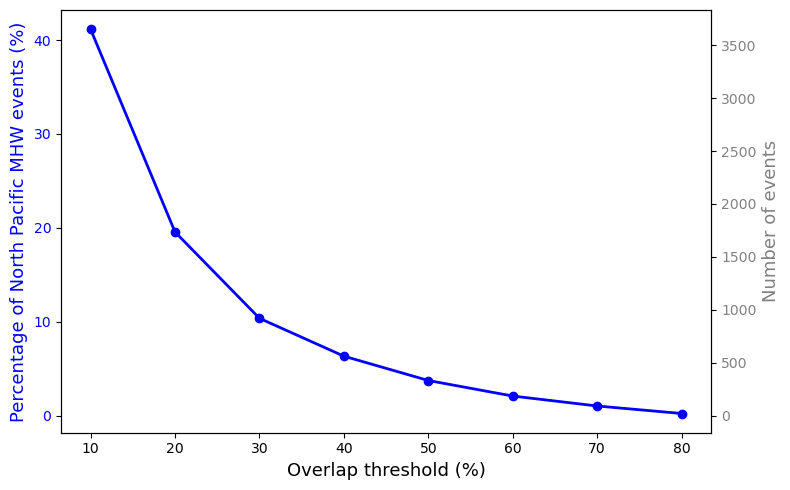

Total N events (linear method): 8873


In [15]:
# Figure S1a - percentage + absolute count, dual y-axis
pct_overlap = 100 * np.array(counts_per_threshold_by_method['linear']) / total_events_by_method['linear']
total_n_events = total_events_by_method['linear']

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(thresholds*100, pct_overlap, color='blue', linewidth=2, marker='o')
ax1.set_xlabel('Overlap threshold (%)', fontsize=13)
ax1.set_ylabel('Percentage of North Pacific MHW events (%)', fontsize=13, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Number of events', fontsize=13, color='gray')
ax2.set_ylim(ax1.get_ylim()[0] * total_n_events / 100, ax1.get_ylim()[1] * total_n_events / 100)
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

print(f"Total N events (linear method): {total_n_events}")

In [65]:
# --- Confirmed Blob mask (Label 94, correct 20-month window) ---
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat','lon')), drop=True)
n_months = len(blob_times)  # should be 20

the_blob = xr.where(fosi_blobs.sel(time=blob_times) == object_id, 1., 0.)

# Fraction of the event's duration each grid cell was part of the footprint
fosi_blob_footprint = the_blob.sum(dim='time') / n_months

# Mask out cells present for 10% or less of the duration (per your Fig S1 caption)
# fosi_blob_footprint_nan = xr.where(fosi_blob_footprint <= 0.1, np.nan, fosi_blob_footprint)

print(f"n_months: {n_months}")  # sanity check - should print 20
print(f"Max fraction: {float(fosi_blob_footprint_nan.max()):.2f}")  # should be <= 1.0

n_months: 20
Max fraction: 0.85


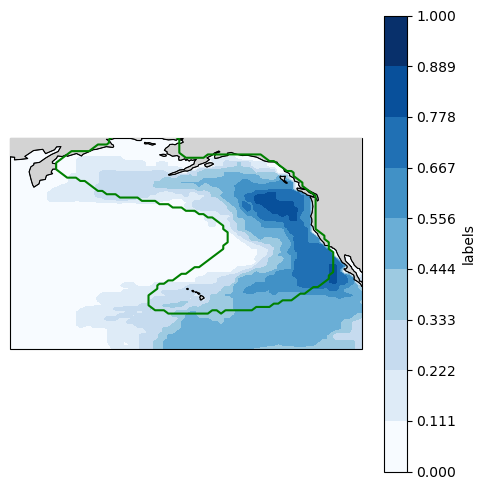

In [72]:
fosi_blob_footprint_display = fosi_blob_footprint_nan.where(fosi_blob_footprint_nan > 0.1)

fig = plt.figure(figsize=(5, 5), facecolor='white')
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_facecolor('white')

im = fosi_blob_footprint.plot.contourf(
    ax=ax, transform=ccrs.PlateCarree(), 
    cmap='Blues', add_colorbar=True,
    vmin=0.0, vmax=1., levels=10,
    extend='neither', zorder=1)

ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5, zorder=10)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)

ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())

mask_3_binary.plot.contour(
    ax=ax, transform=ccrs.PlateCarree(),
    levels=[0.5], colors='green', linewidths=1.5, zorder=20
)

plt.tight_layout()
plt.show()

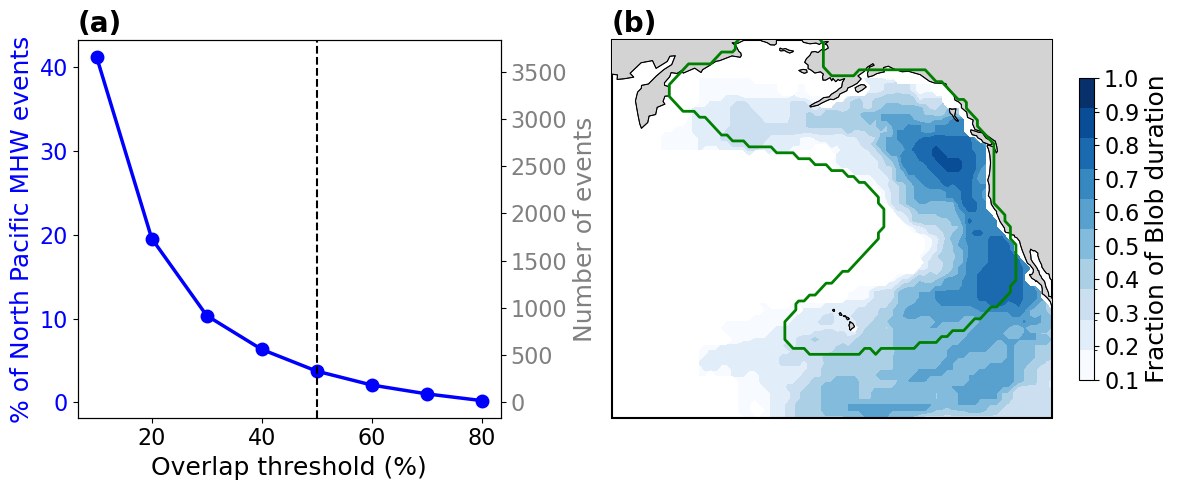

In [84]:
fig = plt.figure(figsize=(12, 5), facecolor='white')
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.3], figure=fig)

# Panel (a)
ax1 = fig.add_subplot(gs[0])

pct_overlap = 100 * np.array(counts_per_threshold_by_method['linear']) / total_events_by_method['linear']
total_n_events = total_events_by_method['linear']

ax1.plot(thresholds*100, pct_overlap, color='blue', linewidth=2.5, marker='o', markersize=9)
ax1.set_xlabel('Overlap threshold (%)', fontsize=18)
ax1.set_ylabel('% of North Pacific MHW events', fontsize=18, color='blue')
ax1.tick_params(axis='y', labelcolor='blue', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)
ax1.axvline(x=50, c='k', linestyle='dashed')
ax2 = ax1.twinx()
ax2.set_ylabel('Number of events', fontsize=18, color='gray')
ax2.set_ylim(ax1.get_ylim()[0] * total_n_events / 100, ax1.get_ylim()[1] * total_n_events / 100)
ax2.tick_params(axis='y', labelcolor='gray', labelsize=16)

ax1.set_title('(a)', loc='left', fontsize=20, fontweight='bold')

# Panel (b)
ax3 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree(central_longitude=180))
ax3.set_facecolor('white')
ax3.set_aspect('auto')

im = fosi_blob_footprint_nan.plot.contourf(
    ax=ax3, transform=ccrs.PlateCarree(),
    levels=np.linspace(0.1, 1.0, 11), cmap='Blues', add_colorbar=True,
    extend='neither', zorder=1,
    cbar_kwargs={'label': 'Fraction of CESM2-FOSI Blob duration', 'shrink': 0.8, 'ticks': np.arange(0.1, 1.01, 0.1)}
)
im.colorbar.set_ticks(np.arange(0.1, 1.01, 0.1))

im.colorbar.ax.tick_params(labelsize=16)
im.colorbar.set_label('Fraction of Blob duration', fontsize=18)

ax3.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5, zorder=10)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)
ax3.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())

mask_3_binary.plot.contour(
    ax=ax3, transform=ccrs.PlateCarree(),
    levels=[0.5], colors='green', linewidths=2, zorder=20
)

for spine in ax3.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

ax3.set_title('(b)', loc='left', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_S1.png', dpi=300, bbox_inches='tight')
plt.show()